<a href="https://colab.research.google.com/github/mvgolubev99/kaggle-chemical-structure-and-logp/blob/dev/logp_baseline_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloads, installs, imports

In [1]:
# download data
!mkdir -p ./data
!curl -L -o ./data/archive_logp.zip https://www.kaggle.com/api/v1/datasets/download/matthewmasters/chemical-structure-and-logp
!unzip ./data/archive_logp.zip -d ./data/
!rm ./data/archive_logp.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 81468  100 81468    0     0  75605      0  0:00:01  0:00:01 --:--:-- 75605
Archive:  ./data/archive_logp.zip
  inflating: ./data/logP_dataset.csv  


In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 38.3 MB/s eta 0:00:00


bulk generators and Features morgan generator somehow are not available in google colab version of rdkit, though it is not outdated (2025.9.1).

Individual generators instead of bulk are used.

Deprecated GetMorganFingerprintAsBitVect instead of GetMorganGenerator GetFeaturesMorganGenerator is used.

So called "Pattern" and "Layered" are not used as they're abscent in colab rdkit.

In [21]:
from pathlib import Path
import glob
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors, MACCSkeys
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import PredictionErrorDisplay

from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.neural_network import MLPRegressor

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Disable RDKit logging to keep output clean

import warnings
# RDKit swears to usage of deprecated GetMorganFingerprintAsBitVect
warnings.filterwarnings("ignore", category=DeprecationWarning)

# lgbm creates column names for features
# even though no arrays or dataframes are passed as arguments to .fit() method
warnings.filterwarnings("ignore", category=UserWarning)


# Fix seed

In [4]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# Data

In [5]:
f = './data/logP_dataset.csv'
data = pd.read_csv(f, names = ['smiles', 'logp'])
data

,smiles,logp
0,C[C@H]([C@@H](C)Cl)Cl,2.3
1,C(C=CBr)N,0.3
2,CCC(CO)Br,1.3
3,[13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O,2.0
4,CCCOCCP,0.6
...,...,...
14605,CCC(SC)Br,2.7
14606,[2H]C([2H])([C@@H](CO)O)O,-1.8
14607,CC(C)NNC,0.4
14608,C[C@H]1CCC[CH]1,3.4


# Convert smiles to fingerprints

## FingerprintRepresentation classes

In [6]:
# ------------------------------------------------------------------
# Base class
# ------------------------------------------------------------------

class BaseFingerprintRepresenation:
    def __init__(self, smiles, *args, **kwargs):
        self.smiles = self._collect_smiles(smiles)
        self.args = args
        self.kwargs = kwargs
        self.mols = [Chem.MolFromSmiles(s) for s in self.smiles]

    def _collect_smiles(self, smiles):
        if isinstance(smiles, list):
            pass
        elif hasattr(smiles, 'to_list'):
            smiles = smiles.to_list()
        else:
            smiles = list(smiles)
        return smiles

    def mol_to_fp(self, mol):
        return np.zeros(1)

    def to_fps(self):
        fps = []
        for mol in self.mols:
            fp = self.mol_to_fp(mol)
            fps.append(fp)
        self.fps = np.array(fps)
        return self.fps

    def save_fps(self, savepath):
        if not hasattr(self, 'fps'):
            raise AttributeError(
                "There is no 'fps' attribute! Nothing to save."
            )
        if not isinstance(self.fps, np.ndarray):
            raise TypeError(
                f"fps attribute is of wrong type: {type(self.fps)}, "
                "but 'np.ndarray' is expected"
            )
        if savepath is None:
            raise ValueError("path should not be None!")
        np.save(savepath, self.fps)

        if Path(savepath).is_file():
            print(f"\nfingerprints saved as \'{savepath}\'")

# ------------------------------------------------------------------
# Morgan (ECFP)
# ------------------------------------------------------------------

class MorganFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        # fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=self.kwargs.get('radius', 2), nBits=self.kwargs.get('nBits', 2048), useFeatures=False,)
        gen = GetMorganGenerator(
            radius=self.kwargs.get('radius', 2),
            fpSize=self.kwargs.get('fpSize', 2048),
        )
        fp = gen.GetFingerprint(mol)
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Features Morgan (FCFP)
# ------------------------------------------------------------------

class FeaturesMorganFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=self.kwargs.get('radius', 2),
            nBits=self.kwargs.get('nBits', 2048),
            useFeatures=True,
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# MACCS keys
# ------------------------------------------------------------------

class MACCSKeysFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = MACCSkeys.GenMACCSKeys(mol)
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# RDKit fingerprint
# ------------------------------------------------------------------

class RDKitFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = Chem.RDKFingerprint(
            mol,
            minPath=self.kwargs.get('minPath', 1),
            maxPath=self.kwargs.get('maxPath', 7),
            fpSize=self.kwargs.get('fpSize', 2048),
            useHs=self.kwargs.get('useHs', True),
            branchedPaths=self.kwargs.get('branchedPaths', True)
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Atom Pair (hashed)
# ------------------------------------------------------------------

class AtomPairFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(
            mol,
            nBits=self.kwargs.get('nBits', 2048)
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Topological Torsion (hashed)
# ------------------------------------------------------------------

class TopologicalTorsionFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(
            mol,
            nBits=self.kwargs.get('nBits', 2048)
        )
        return np.array(fp, dtype=int)

# ------------------------------------------------------------------
# Avalon fingerprint
# ------------------------------------------------------------------

class AvalonFingerprint(BaseFingerprintRepresenation):
    def mol_to_fp(self, mol):
        fp = pyAvalonTools.GetAvalonFP(
            mol,
            nBits=self.kwargs.get('nBits', 1024)
        )
        return np.array(fp, dtype=int)


# register all classes
FINGERPRINT_CLASSES = {
    "MorganFingerprint_2048": MorganFingerprint,
    'FeaturesMorganFingerprint_2048': FeaturesMorganFingerprint,
    "MACCSKeysFingerprint_167": MACCSKeysFingerprint,
    "RDKitFingerprint_2048": RDKitFingerprint,
    "AtomPairFingerprint_2048": AtomPairFingerprint,
    "TopologicalTorsionFingerprint_2048": TopologicalTorsionFingerprint,
    "AvalonFingerprint_1024": AvalonFingerprint,
}

def get_fingerprint_class(name: str):
    """Returns fingerprint class by its name"""
    name = name.lower()
    if name not in FINGERPRINT_CLASSES:
        raise ValueError(f"Unknown fingerprint type: {name}")
    return FINGERPRINT_CLASSES[name]


## Test

Lets test mol_to_fp method of fingerprint class on single molecule

In [7]:
# Test molecule (benzene)
test_smiles = ["c1ccccc1"]

print("Testing mol_to_fp method in all fingerprint classes...\n")

for name, fp_class in FINGERPRINT_CLASSES.items():
    print(f"Testing: {name}")
    try:
        # Create an instance of the fingerprint class
        fp_instance = fp_class(test_smiles)

        # Generate fingerprints
        fps = fp_instance.to_fps()

        # Check that the result is a numpy array
        if not isinstance(fps, np.ndarray):
            print(f"{name}: result is not np.ndarray, but {type(fps)}")
        elif fps.ndim != 2:
            print(f"{name}: result is np.ndarray but has unusual shape: {fps.shape}")
        else:
            print(f"{name}: OK, type {type(fps)}, shape {fps.shape}")
    except Exception as e:
        print(f"{name}:error during calculation — {type(e).__name__}: {e}")
    print()


Testing mol_to_fp method in all fingerprint classes...

Testing: MorganFingerprint_2048
MorganFingerprint_2048: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: FeaturesMorganFingerprint_2048
FeaturesMorganFingerprint_2048: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: MACCSKeysFingerprint_167
MACCSKeysFingerprint_167: OK, type <class 'numpy.ndarray'>, shape (1, 167)

Testing: RDKitFingerprint_2048
RDKitFingerprint_2048: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: AtomPairFingerprint_2048
AtomPairFingerprint_2048: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: TopologicalTorsionFingerprint_2048
TopologicalTorsionFingerprint_2048: OK, type <class 'numpy.ndarray'>, shape (1, 2048)

Testing: AvalonFingerprint_1024
AvalonFingerprint_1024: OK, type <class 'numpy.ndarray'>, shape (1, 1024)



## Convert data

In [8]:
# approx. 1 minute

def convert_data_from_smiles_to_fingerprints(
        folder_to_save, # ./data
        fingerprint_classes, # FINGERPRINT_CLASSES
        replace=False,
    ):
    print("Converting data from smiles to all fingerprints...")

    folder_to_save = Path(folder_to_save)
    if not folder_to_save.is_dir():
        raise FileNotFoundError(f"no such directory: {folder_to_save}")

    print(f"\nsaving fingerprints to folder: \'{folder_to_save}'\n")

    for k, (fp_name, fp_class) in enumerate(fingerprint_classes.items()):
        print(
            f"[{k+1}/{len(fingerprint_classes)}]\n"
            f"fp_name={fp_name}",
            end = ' ')

        savepath = folder_to_save / f"{fp_name}_X_data.npy"

        if savepath.is_file() and not replace:
            print(f"\nskipping {fp_name}, \'{savepath}\' already exists\n")
            continue

        fp_instance = fp_class(data['smiles'])
        fp_instance.to_fps()
        fp_instance.save_fps(savepath=savepath)

        print(f"\nfps.shape={fp_instance.fps.shape}")

convert_data_from_smiles_to_fingerprints(
    folder_to_save='./data',
    fingerprint_classes=FINGERPRINT_CLASSES,
)

Converting data from smiles to all fingerprints...

saving fingerprints to folder: 'data'

[1/7]
fp_name=MorganFingerprint_2048 
fingerprints saved as 'data/MorganFingerprint_2048_X_data.npy'

fps.shape=(14610, 2048)
[2/7]
fp_name=FeaturesMorganFingerprint_2048 
fingerprints saved as 'data/FeaturesMorganFingerprint_2048_X_data.npy'

fps.shape=(14610, 2048)
[3/7]
fp_name=MACCSKeysFingerprint_167 
fingerprints saved as 'data/MACCSKeysFingerprint_167_X_data.npy'

fps.shape=(14610, 167)
[4/7]
fp_name=RDKitFingerprint_2048 
fingerprints saved as 'data/RDKitFingerprint_2048_X_data.npy'

fps.shape=(14610, 2048)
[5/7]
fp_name=AtomPairFingerprint_2048 
fingerprints saved as 'data/AtomPairFingerprint_2048_X_data.npy'

fps.shape=(14610, 2048)
[6/7]
fp_name=TopologicalTorsionFingerprint_2048 
fingerprints saved as 'data/TopologicalTorsionFingerprint_2048_X_data.npy'

fps.shape=(14610, 2048)
[7/7]
fp_name=AvalonFingerprint_1024 
fingerprints saved as 'data/AvalonFingerprint_1024_X_data.npy'

fps.sh

# Split data

Here we just use random splitting of data. But in general, we should pay attention to splitting method because simple random splitting may lead to overestimation of model quality due to data leakage.

In previous version (which was generated by chatgpt using one prompt, lol) i did not notice signigicant differences between butina split and random split. Murcko scaffold split cannot be applied here, because most of molecules from this dataset will be assigned with empty scaffold.

split indices and then access data by them

In [9]:
data_ids =  data.index.to_numpy()
train_ids, test_ids = train_test_split(data_ids, random_state=42)
train_ids, val_ids = train_test_split(train_ids, random_state=42)

In [10]:
print(
    f"train set size:\t{len(train_ids)}\n"
    f"val set size:\t{len(val_ids)}\n"
    f"test set size:\t{len(test_ids)}"
)

train set size:	8217
val set size:	2740
test set size:	3653


In [11]:
y_train = data['logp'].iloc[train_ids].values.reshape(-1, 1)
y_val = data['logp'].iloc[val_ids].values.reshape(-1, 1)

y_train, y_val, y_test = [
    data['logp'].iloc[ids].values.reshape(-1, 1) for ids in [train_ids, val_ids, test_ids]
]

In [12]:
len(y_train), len(y_val), len(y_test)

(8217, 2740, 3653)

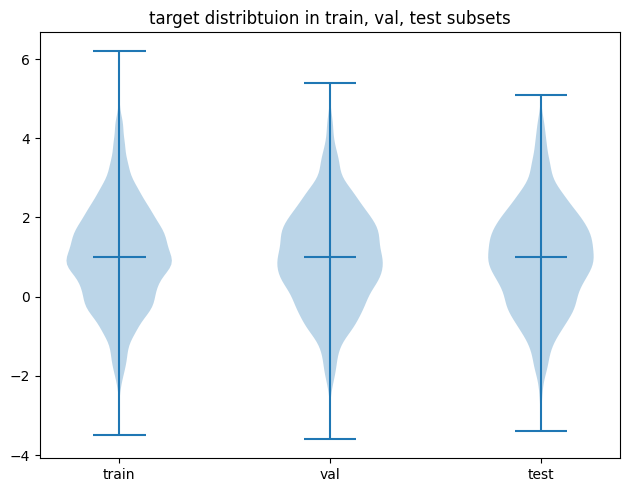

In [13]:
def plot_target_distributions(target, **ids):
    """
    Draws violin plots comparing target distributions for each fold's train/test
    subsets and the final test set.
    """
    #plt.figure(figsize=(4*len(ids),len(ids)))
    plt.figure()
    data = []
    labels = []
    for name, data_ids in ids.items():
        data.append(target.iloc[data_ids].values)
        labels.append(name)

    plt.violinplot(data, showmedians=True)
    plt.xticks(range(1, len(ids) + 1), labels=ids.keys())
    #plt.xticklabels(ids.keys(), rotation=20)
    plt.tight_layout()
    plt.title(f"target distribtuion in {', '.join(ids.keys())} subsets")
    plt.show()


plot_target_distributions(
    target = data['logp'],
    train=train_ids,
    val=val_ids,
    test=test_ids,
)

In [14]:
def make_k_fold_split_ids(
    data_ids,
    n_splits=5,
    random_state=42,
    shuffle=True,
    ):
    """
    This function returns list of folds, where
    each fold contains indices of 'train' and 'test' subset.
    """
    splitter = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    folds_ids = []
    # No list comprehension for better readability.
    # Do not be confused! Unlike train_test_split,
    # KFold.split() method return indices of 'train' and 'test',
    # not the actual data
    for train_ids, test_ids in splitter.split(data_ids):
        fold_ids = {
            'train': data_ids[train_ids],
            'test': data_ids[test_ids],
        }
        folds_ids.append(fold_ids)
    return folds_ids

folds_ids = make_k_fold_split_ids(train_ids)

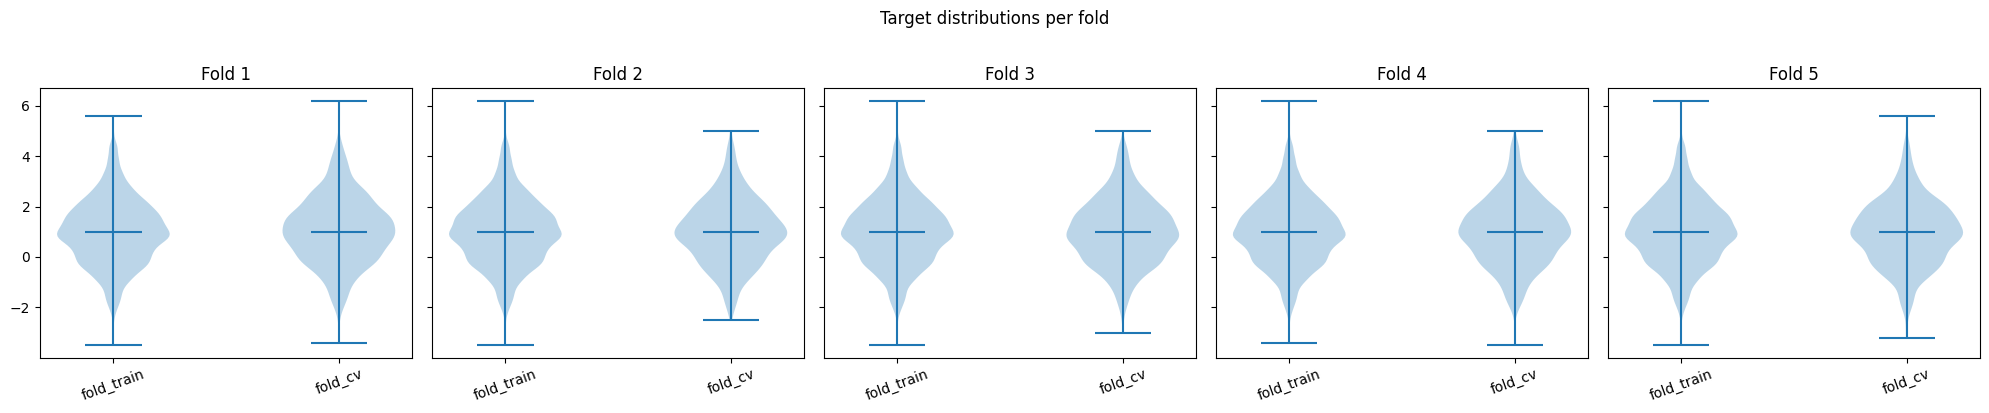

In [15]:
def plot_target_distributions_cv(target, folds_ids):
    """
    Draws violin plots comparing target distributions for each fold's train/test
    subsets and the final test set.
    """
    n_splits = len(folds_ids)
    fig, axes = plt.subplots(1, n_splits, figsize=(4 * n_splits, 4), sharey=True)

    if n_splits == 1:
        axes = [axes]

    for i, fold in enumerate(folds_ids):
        data = [
            target.iloc[fold['train']],
            target.iloc[fold['test']],
        ]
        labels = ['fold_train', 'fold_cv']
        axes[i].violinplot(data, showmedians=True)
        axes[i].set_xticks(range(1, len(labels) + 1))
        axes[i].set_xticklabels(labels, rotation=20)
        axes[i].set_title(f'Fold {i+1}')

    fig.suptitle('Target distributions per fold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_target_distributions_cv(data['logp'], folds_ids)

Also, attention should be paid to target disbalance.

Luckily enough, random splitting of this exact dataset does not lead to any significant target disbalance.

But scaffold aware (or any group aware) splitting methods could lead to target disbalance.

# Pipeline

In [16]:
class TransformedTargetRegressor_with_custom_metric(TransformedTargetRegressor):
    def __init__(
            self,
            regressor=None,
            transformer=None,
            func=None,
            inverse_func=None,
            check_inverse=True,
            score_metric='root_mean_squared_error',
            #**kwargs,
        ):
        super().__init__(
            regressor=regressor,
            transformer=transformer,
            func=func,
            inverse_func=inverse_func,
            check_inverse=check_inverse,
            #**kwargs,
        )
        self.score_metric = score_metric

    def _get_scoring_func_from_score_metric(self):
        if callable(self.score_metric):
            return self.score_metric

        if not isinstance(self.score_metric, str):
            raise TypeError(f"score_metric expected to be string or callable!")

        if self.score_metric == 'root_mean_squared_error':
            from sklearn.metrics import root_mean_squared_error
            return root_mean_squared_error

        if self.score_metric == 'r2_score':
            from sklearn.metrics import r2_score
            return r2_score

        if self.score_metric == 'mean_absolute_error':
            from sklearn.metrics import mean_absolute_error
            return mean_absolute_error

        # there might be other metrics
        # ...

        # raise error if score_metric is not callable and was not found anywhere
        raise ValueError(
            f"score_metric={self.score_metric} is not a valid scoring value"
        )

    def score(
            self,
            X,
            y,
            **kwargs,
        ):
        scoring = self._get_scoring_func_from_score_metric()
        y_pred = self.predict(X)
        score = scoring(y, y_pred, **kwargs)
        # r2_score should be maximized,
        # rmse, mae should be minimized
        if self.score_metric not in ['r2_score']:
            score *= -1
        return score

In [17]:
from sklearn.base import BaseEstimator

class FpFromFileTransform(BaseEstimator):
    def __init__(self, path=None, cash_fp=True):
        self.path = path
        self.cash_fp=cash_fp

    def fit(self, X, y=None):
        self.X_fp_data = np.load(self.path) if self.cash_fp else None
        return self

    def transform(self, X):
        if self.X_fp_data is None:
            X_fp_data = np.load(self.path)
        else:
            X_fp_data = self.X_fp_data
        return X_fp_data[X]

In [18]:
def construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
        regressor__fp_transform__path,
        regressor__fp_transform__cash_fp=True,
        regressor__model=LGBMRegressor(random_state=42, verbose=-1),
        transformer=StandardScaler(), # transformer for y
    ):
    if not Path(regressor__fp_transform__path).is_file():
        raise ValueError(f"Path {regressor__fp_transform__path} do not exist")

    regressor = Pipeline(
        steps=[
            ('fp_transform', FpFromFileTransform(
                path=regressor__fp_transform__path,
                cash_fp=regressor__fp_transform__cash_fp,
                )),
            ('model', regressor__model),
        ]
    )

    pipe = TransformedTargetRegressor_with_custom_metric(
        regressor=regressor,
        transformer=transformer,
    )
    return pipe

In [19]:
def parity_plot(estimator, x, y_true, title=None):
    y_pred = estimator.predict(x)
    score = abs(estimator.score(x, y_true))

    score_name = 'abs(score)'
    if hasattr(estimator, 'score_metric'):
        score_name = estimator.score_metric

    plotter=PredictionErrorDisplay(
        y_true=y_true,
        y_pred=y_pred
    )

    fig, ax = plt.subplots()
    plotter.plot(ax=ax, kind="actual_vs_predicted")
    ax.set_title(
        ', '.join([
            f"{title}",
            f"{score_name}={score:.6f}"
        ])
    )
    plt.show()


testing DummyRegressor

In [20]:
print("DummyRegressor")
pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    '/content/data/MorganFingerprint_2048_X_data.npy',
    regressor__model = DummyRegressor(strategy='median'),
)

pipe.fit(X=train_ids, y=y_train)
val_score = pipe.score(X=val_ids, y=y_val)
print(f"{pipe.score_metric} on validation: {abs(val_score)}")

DummyRegressor
root_mean_squared_error on validation: 1.2790921164387523


# GridSearchCV all fingerprints with LGBM, XGB, Ridge, Lasso

In [ ]:
pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    '/content/data/MorganFingerprint_2048_X_data.npy',
)

param_grid = {
    'regressor__fp_transform__path': glob.glob("./data/*X_data.npy"),
    'regressor__model': [
        DummyRegressor(strategy='median'),
        LGBMRegressor(random_state=42, verbose=0),
        XGBRegressor(random_state=42, verbose=0),
        Ridge(random_state=42),
        Lasso(random_state=42),
    ],
}

gscv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    verbose=3,
)

In [ ]:
# approx. 3 minutes
gscv.fit(X=train_ids, y=y_train)

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV 1/5] END regressor__fp_transform__path=./data/TopologicalTorsionFingerprint_2048_X_data.npy, regressor__model=DummyRegressor(strategy='median');, score=-1.333 total time=   0.2s
[CV 2/5] END regressor__fp_transform__path=./data/TopologicalTorsionFingerprint_2048_X_data.npy, regressor__model=DummyRegressor(strategy='median');, score=-1.292 total time=   0.2s
[CV 3/5] END regressor__fp_transform__path=./data/TopologicalTorsionFingerprint_2048_X_data.npy, regressor__model=DummyRegressor(strategy='median');, score=-1.289 total time=   0.2s
[CV 4/5] END regressor__fp_transform__path=./data/TopologicalTorsionFingerprint_2048_X_data.npy, regressor__model=DummyRegressor(strategy='median');, score=-1.308 total time=   0.2s
[CV 5/5] END regressor__fp_transform__path=./data/TopologicalTorsionFingerprint_2048_X_data.npy, regressor__model=DummyRegressor(strategy='median');, score=-1.304 total time=   0.1s
[CV 1/5] END regressor__fp_t

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                FpFromFileTransform(path='/content/data/MorganFingerprint_2048_X_data.npy')),
                                                                                               ('model',
                                                                                                LGBMRegressor(random_state=42,
                                                                                                              verbose=-1))]),
                                                                     transformer=StandardScaler()),
             param_grid={'regressor__fp_t...
                                                           interaction_constraints=None,
                                                           learning_rate=None,
                                                           max_bin=None,
                                                           max_cat_threshold=None,
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=None,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...),
                                              Ridge(random_state=42),
                                              Lasso(random_state=42)]},
             verbose=3)

In [ ]:
gscv.cv_results_

{'mean_fit_time': array([0.14825668, 0.43398442, 3.91859126, 1.88679237, 0.83796692,
        0.16104689, 1.10253949, 4.91946931, 2.14379015, 0.48223815,
        0.07638249, 0.53744144, 2.46928802, 0.61599941, 0.33841591,
        0.17207842, 0.50529351, 3.87147107, 2.71964793, 0.48636899,
        0.29794822, 0.86184402, 4.10599213, 2.22541294, 0.50882835,
        0.02246494, 0.19270902, 0.93064685, 0.08637185, 0.04758863,
        0.14618263, 0.56326985, 4.36401792, 1.9197547 , 0.58418126]),
 'std_fit_time': array([0.00799519, 0.03633135, 0.99920393, 0.13805009, 0.45165992,
        0.03022332, 0.04950005, 1.22815388, 0.55132415, 0.05903792,
        0.00581489, 0.02283911, 0.9397302 , 0.05090323, 0.02688586,
        0.02649948, 0.12995274, 0.90458648, 0.93815432, 0.03392112,
        0.26050854, 0.24500663, 0.92278049, 0.48785799, 0.03811909,
        0.02132833, 0.01038728, 0.6720502 , 0.03612611, 0.01518861,
        0.01083475, 0.02404432, 1.09125667, 0.19853762, 0.08169344]),
 'mean_scor

In [ ]:
gscv.best_params_

{'regressor__fp_transform__path': './data/MACCSKeysFingerprint_167_X_data.npy',
 'regressor__model': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)}

In [ ]:
gscv.best_score_

np.float64(-0.3170670159921186)

In [ ]:
df_results=pd.DataFrame(gscv.cv_results_)
df_results['mean_test_score'] = df_results['mean_test_score'].abs()
df_results['fp_type'] = df_results['param_regressor__fp_transform__path'].apply(
    lambda s: Path(s).stem.replace('_X_data',''),
)
df_results['model_type'] = df_results['param_regressor__model'].apply(
    lambda s: s.__repr__().split('(')[0],
)
df_results.sort_values(['mean_test_score'], inplace=True)
df_results[['fp_type', 'model_type', 'mean_test_score', 'std_test_score', 'mean_fit_time']]

,fp_type,model_type,mean_test_score,std_test_score,mean_fit_time
27,MACCSKeysFingerprint_167,XGBRegressor,0.317067,0.005958,0.930647
26,MACCSKeysFingerprint_167,LGBMRegressor,0.342494,0.011659,0.192709
12,AvalonFingerprint_1024,XGBRegressor,0.346166,0.015885,2.469288
11,AvalonFingerprint_1024,LGBMRegressor,0.348018,0.012465,0.537441
7,RDKitFingerprint_2048,XGBRegressor,0.405484,0.003613,4.919469
6,RDKitFingerprint_2048,LGBMRegressor,0.438847,0.006490,1.102539
28,MACCSKeysFingerprint_167,Ridge,0.459557,0.010531,0.086372
32,AtomPairFingerprint_2048,XGBRegressor,0.461875,0.005227,4.364018
31,AtomPairFingerprint_2048,LGBMRegressor,0.466621,0.002789,0.563270
13,AvalonFingerprint_1024,Ridge,0.478783,0.011277,0.615999


In [ ]:
gscv.best_estimator_.score_metric

'root_mean_squared_error'

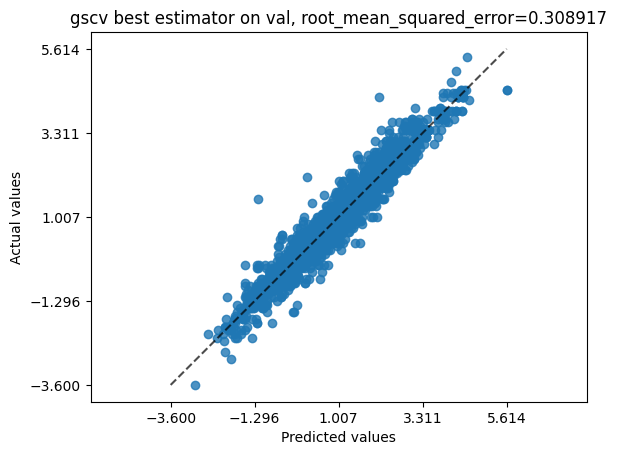

In [ ]:
parity_plot(
    estimator=gscv.best_estimator_,
    x=val_ids,
    y_true=y_val,
    title="gscv best estimator on val",
)

# RandomizedSearchCV

## All fingerprints XGB

In [ ]:
xgb_param_grid = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.5, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

xgb_param_grid = {
    f"regressor__model__{key}": value for key, value in xgb_param_grid.items()
}

rs_xgb_param_grid = []
for fp_path in glob.glob("./data/*X_data.npy"):
    param_grid_i = copy.deepcopy(xgb_param_grid)
    param_grid_i['regressor__fp_transform__path']=[fp_path]
    rs_xgb_param_grid.append(param_grid_i)

In [ ]:
from sklearn.model_selection import ParameterGrid
ParameterGrid(rs_xgb_param_grid)

In [ ]:
pipe_rs = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    regressor__fp_transform__path='/content/data/MorganFingerprint_2048_X_data.npy',
    regressor__model=gscv.best_params_['regressor__model']
)
rs = RandomizedSearchCV(
    estimator=pipe_rs,
    param_distributions=rs_xgb_param_grid,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    verbose=3,
    n_iter=32,
    random_state=42,
)

In [ ]:
# approx. 18 min
rs.fit(X=train_ids, y=y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END regressor__fp_transform__path=./data/FeaturesMorganFingerprint_2048_X_data.npy, regressor__model__colsample_bytree=0.8, regressor__model__gamma=0.5, regressor__model__learning_rate=0.1, regressor__model__max_depth=5, regressor__model__min_child_weight=5, regressor__model__n_estimators=200, regressor__model__reg_alpha=1, regressor__model__reg_lambda=10, regressor__model__subsample=1.0;, score=-0.819 total time=   9.0s
[CV 2/5] END regressor__fp_transform__path=./data/FeaturesMorganFingerprint_2048_X_data.npy, regressor__model__colsample_bytree=0.8, regressor__model__gamma=0.5, regressor__model__learning_rate=0.1, regressor__model__max_depth=5, regressor__model__min_child_weight=5, regressor__model__n_estimators=200, regressor__model__reg_alpha=1, regressor__model__reg_lambda=10, regressor__model__subsample=1.0;, score=-0.816 total time=   5.6s
[CV 3/5] END regressor__fp_transform__path=./data/FeaturesMorganFinger

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                      FpFromFileTransform(path='/content/data/MorganFingerprint_2048_X_data.npy')),
                                                                                                     ('model',
                                                                                                      XGBRegressor(base_score=None,
                                                                                                                   booster=None,
                                                                                                                   callbacks=None,
                                                                                                                   colsample_bylevel=None,
                                                                                                                   colsample_bynode=...
                                         'regressor__model__gamma': [0, 0.5, 1,
                                                                     5],
                                         'regressor__model__learning_rate': [0.01,
                                                                             0.05,
                                                                             0.1],
                                         'regressor__model__max_depth': [3, 5,
                                                                         7, 9],
                                         'regressor__model__min_child_weight': [1,
                                                                                3,
                                                                                5],
                                         'regressor__model__n_estimators': [100,
                                                                            200,
                                                                            400],
                                         'regressor__model__reg_alpha': [0, 0.1,
                                                                         1],
                                         'regressor__model__reg_lambda': [1, 5,
                                                                          10],
                                         'regressor__model__subsample': [0.6,
                                                                         0.8,
                                                                         1.0]}],
                   random_state=42, verbose=3)

In [ ]:
rs.cv_results_

In [ ]:
rs.best_params_

{'regressor__model__subsample': 0.8,
 'regressor__model__reg_lambda': 5,
 'regressor__model__reg_alpha': 0.1,
 'regressor__model__n_estimators': 100,
 'regressor__model__min_child_weight': 3,
 'regressor__model__max_depth': 9,
 'regressor__model__learning_rate': 0.05,
 'regressor__model__gamma': 0.5,
 'regressor__model__colsample_bytree': 0.8,
 'regressor__fp_transform__path': './data/MACCSKeysFingerprint_167_X_data.npy'}

In [ ]:
rs.best_score_

np.float64(-0.36790770749635365)

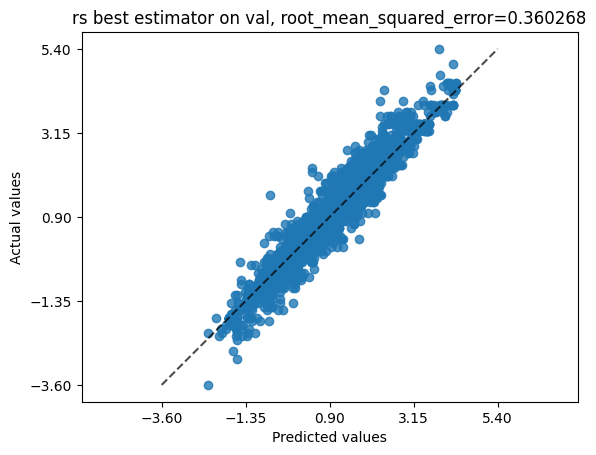

In [ ]:
parity_plot(
    estimator=rs.best_estimator_,
    x=val_ids,
    y_true=y_val,
    title="rs best estimator on val",
)

## MACCS keys XGB _1

In [ ]:
maccs_xgb_param_grid = {
    'n_estimators': [50, 100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.5, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

maccs_xgb_param_grid = {
    f"regressor__model__{key}": value for key, value in xgb_param_grid.items()
}

pipe_rs_maccs = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    regressor__fp_transform__path='/content/data/MACCSKeysFingerprint_167_X_data.npy',
    regressor__model=gscv.best_params_['regressor__model']
)
rs_maccs = RandomizedSearchCV(
    estimator=pipe_rs_maccs,
    param_distributions=maccs_xgb_param_grid,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    verbose=3,
    n_iter=32,
    random_state=42,
)

In [ ]:
# approx. 18 min
rs_maccs.fit(X=train_ids, y=y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END regressor__model__regressor__model__colsample_bytree=0.8, regressor__model__regressor__model__gamma=0.5, regressor__model__regressor__model__learning_rate=0.05, regressor__model__regressor__model__max_depth=5, regressor__model__regressor__model__min_child_weight=1, regressor__model__regressor__model__n_estimators=100, regressor__model__regressor__model__reg_alpha=0, regressor__model__regressor__model__reg_lambda=1, regressor__model__regressor__model__subsample=0.6;, score=-0.323 total time=   1.1s
[CV 2/5] END regressor__model__regressor__model__colsample_bytree=0.8, regressor__model__regressor__model__gamma=0.5, regressor__model__regressor__model__learning_rate=0.05, regressor__model__regressor__model__max_depth=5, regressor__model__regressor__model__min_child_weight=1, regressor__model__regressor__model__n_estimators=100, regressor__model__regressor__model__reg_alpha=0, regressor__model__regressor__model__reg_

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                      FpFromFileTransform(path='/content/data/MACCSKeysFingerprint_167_X_data.npy')),
                                                                                                     ('model',
                                                                                                      XGBRegressor(base_score=None,
                                                                                                                   booster=None,
                                                                                                                   callbacks=None,
                                                                                                                   colsample_bylevel=None,
                                                                                                                   colsample_bynod...
                                        'regressor__model__regressor__model__max_depth': [3,
                                                                                          5,
                                                                                          7,
                                                                                          9],
                                        'regressor__model__regressor__model__min_child_weight': [1,
                                                                                                 3,
                                                                                                 5],
                                        'regressor__model__regressor__model__n_estimators': [100,
                                                                                             200,
                                                                                             400],
                                        'regressor__model__regressor__model__reg_alpha': [0,
                                                                                          0.1,
                                                                                          1],
                                        'regressor__model__regressor__model__reg_lambda': [1,
                                                                                           5,
                                                                                           10],
                                        'regressor__model__regressor__model__subsample': [0.6,
                                                                                          0.8,
                                                                                          1.0]},
                   random_state=42, verbose=3)

In [ ]:
rs_maccs.best_params_

{'regressor__model__regressor__model__subsample': 0.6,
 'regressor__model__regressor__model__reg_lambda': 1,
 'regressor__model__regressor__model__reg_alpha': 0,
 'regressor__model__regressor__model__n_estimators': 100,
 'regressor__model__regressor__model__min_child_weight': 1,
 'regressor__model__regressor__model__max_depth': 5,
 'regressor__model__regressor__model__learning_rate': 0.05,
 'regressor__model__regressor__model__gamma': 0.5,
 'regressor__model__regressor__model__colsample_bytree': 0.8}

In [ ]:
rs_maccs.best_score_

np.float64(-0.3170670159921186)

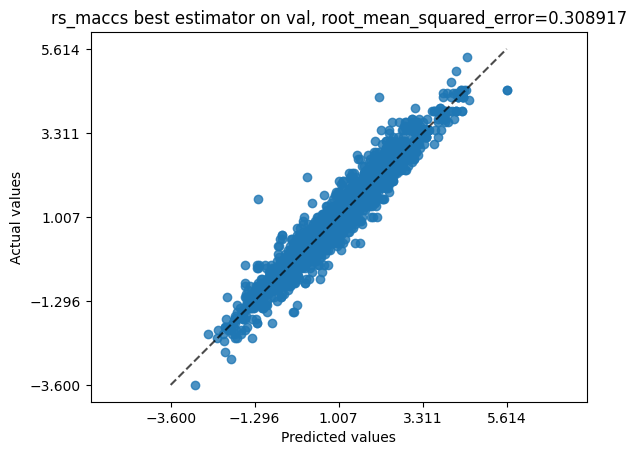

In [ ]:
parity_plot(
    estimator=rs_maccs.best_estimator_,
    x=val_ids,
    y_true=y_val,
    title="rs_maccs best estimator on val",
)

## MACCS keys XGB _2

In [ ]:
maccs_xgb_param_grid = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.5, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

maccs_xgb_param_grid = {
    f"regressor__model__{key}": value for key, value in xgb_param_grid.items()
}

pipe_rs_maccs = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    regressor__fp_transform__path='/content/data/MACCSKeysFingerprint_167_X_data.npy',
    regressor__model=gscv.best_params_['regressor__model']
)
rs_maccs = RandomizedSearchCV(
    estimator=pipe_rs_maccs,
    param_distributions=maccs_xgb_param_grid,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    verbose=3,
    n_iter=32,
    random_state=42,
)

In [ ]:
# approx. 18 min
rs_maccs.fit(X=train_ids, y=y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END regressor__model__regressor__model__colsample_bytree=0.8, regressor__model__regressor__model__gamma=0.5, regressor__model__regressor__model__learning_rate=0.05, regressor__model__regressor__model__max_depth=5, regressor__model__regressor__model__min_child_weight=1, regressor__model__regressor__model__n_estimators=100, regressor__model__regressor__model__reg_alpha=0, regressor__model__regressor__model__reg_lambda=1, regressor__model__regressor__model__subsample=0.6;, score=-0.323 total time=   1.1s
[CV 2/5] END regressor__model__regressor__model__colsample_bytree=0.8, regressor__model__regressor__model__gamma=0.5, regressor__model__regressor__model__learning_rate=0.05, regressor__model__regressor__model__max_depth=5, regressor__model__regressor__model__min_child_weight=1, regressor__model__regressor__model__n_estimators=100, regressor__model__regressor__model__reg_alpha=0, regressor__model__regressor__model__reg_

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                      FpFromFileTransform(path='/content/data/MACCSKeysFingerprint_167_X_data.npy')),
                                                                                                     ('model',
                                                                                                      XGBRegressor(base_score=None,
                                                                                                                   booster=None,
                                                                                                                   callbacks=None,
                                                                                                                   colsample_bylevel=None,
                                                                                                                   colsample_bynod...
                                        'regressor__model__regressor__model__max_depth': [3,
                                                                                          5,
                                                                                          7,
                                                                                          9],
                                        'regressor__model__regressor__model__min_child_weight': [1,
                                                                                                 3,
                                                                                                 5],
                                        'regressor__model__regressor__model__n_estimators': [100,
                                                                                             200,
                                                                                             400],
                                        'regressor__model__regressor__model__reg_alpha': [0,
                                                                                          0.1,
                                                                                          1],
                                        'regressor__model__regressor__model__reg_lambda': [1,
                                                                                           5,
                                                                                           10],
                                        'regressor__model__regressor__model__subsample': [0.6,
                                                                                          0.8,
                                                                                          1.0]},
                   random_state=42, verbose=3)

In [ ]:
rs_maccs.best_params_

{'regressor__model__regressor__model__subsample': 0.6,
 'regressor__model__regressor__model__reg_lambda': 1,
 'regressor__model__regressor__model__reg_alpha': 0,
 'regressor__model__regressor__model__n_estimators': 100,
 'regressor__model__regressor__model__min_child_weight': 1,
 'regressor__model__regressor__model__max_depth': 5,
 'regressor__model__regressor__model__learning_rate': 0.05,
 'regressor__model__regressor__model__gamma': 0.5,
 'regressor__model__regressor__model__colsample_bytree': 0.8}

In [ ]:
rs_maccs.best_score_

np.float64(-0.3170670159921186)

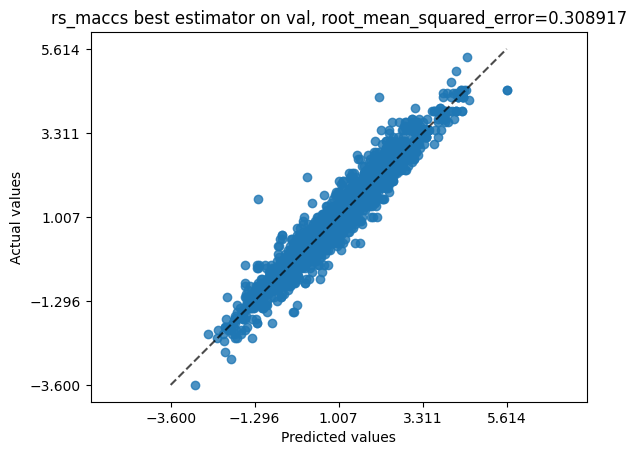

In [ ]:
parity_plot(
    estimator=rs_maccs.best_estimator_,
    x=val_ids,
    y_true=y_val,
    title="rs_maccs best estimator on val",
)

# Optuna MACCS XGB

In [48]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.3 MB/s eta 0:00:00


In [57]:
import optuna
from sklearn.model_selection import cross_val_score, KFold

def xgb_objective(trial):
    xgb_params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
    }
    model = XGBRegressor(**xgb_params, random_state=42, verbose=0)

    pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
        regressor__fp_transform__path='/content/data/MACCSKeysFingerprint_167_X_data.npy',
        regressor__model=model,
    )

    scores = cross_val_score(
        pipe,
        X=train_ids,
        y=y_train,
        cv=KFold(n_splits=5, random_state=42, shuffle=True),
        scoring='neg_root_mean_squared_error',
    )
    return -scores.mean()

# fix seed!
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(xgb_objective, n_trials=64)
print(study.best_trial.params)


[I 2025-11-12 16:46:39,316] A new study created in memory with name: no-name-050ce1bc-e104-4ff0-aaa6-b994b13a9737
[I 2025-11-12 16:46:44,185] Trial 0 finished with value: 0.38468166680761334 and parameters: {'n_estimators': 687, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.38468166680761334.
[I 2025-11-12 16:46:58,005] Trial 1 finished with value: 0.39538382122498544 and parameters: {'n_estimators': 1121, 'learning_rate': 0.010725209743171997, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.9170225492671691, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.6237821581611893}. Best is trial 0 with value: 0.38468166680761334.
[I 2025-11-12 16:47:05,861] Trial 2 finished with value: 0.44183

{'n_estimators': 727, 'learning_rate': 0.17286595139334485, 'max_depth': 8, 'min_child_weight': 10, 'subsample': 0.800722196657914, 'colsample_bytree': 0.7430544270152778, 'gamma': 0.021345958158534906, 'reg_alpha': 0.4737891198411529, 'reg_lambda': 4.993204662796431}


In [58]:
model = XGBRegressor(**study.best_trial.params, random_state=42, verbose=0)

pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    regressor__fp_transform__path='/content/data/MACCSKeysFingerprint_167_X_data.npy',
    regressor__model=model,
)

pipe.fit(X=train_ids, y=y_train)
val_score = pipe.score(X=val_ids, y=y_val)
print(f"{pipe.score_metric} on validation: {abs(val_score)}")

root_mean_squared_error on validation: 0.2816164491590626


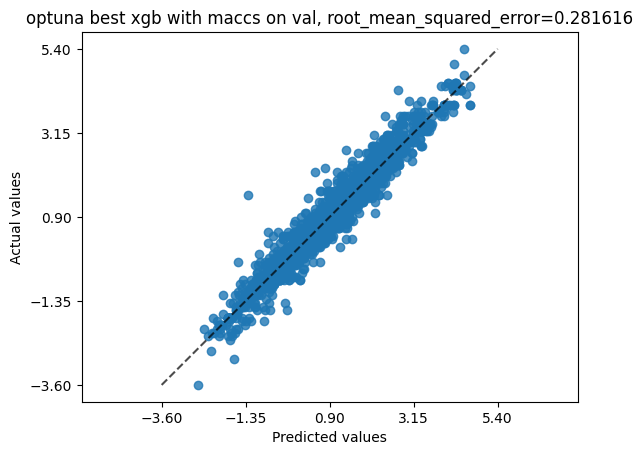

In [59]:
parity_plot(
    estimator=pipe,
    x=val_ids,
    y_true=y_val,
    title="optuna best xgb with maccs on val",
)

# Optuna avalon XGB

In [53]:
import optuna
from sklearn.model_selection import cross_val_score, KFold

def xgb_avalon_objective(trial):
    xgb_params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
    }
    model = XGBRegressor(**xgb_params, random_state=42, verbose=0)

    pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
        regressor__fp_transform__path='/content/data/AvalonFingerprint_1024_X_data.npy',
        regressor__model=model,
    )

    scores = cross_val_score(
        pipe,
        X=train_ids,
        y=y_train,
        cv=KFold(n_splits=5, random_state=42, shuffle=True),
        scoring='neg_root_mean_squared_error',
    )
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study_avalon = optuna.create_study(direction='minimize', sampler=sampler)
study_avalon.optimize(xgb_avalon_objective, n_trials=32)


[I 2025-11-12 16:01:02,583] A new study created in memory with name: no-name-5a1c1272-6346-4142-8ba3-025e2e205226
[I 2025-11-12 16:01:33,590] Trial 0 finished with value: 0.40009316765654745 and parameters: {'n_estimators': 687, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.40009316765654745.
[I 2025-11-12 16:02:53,144] Trial 1 finished with value: 0.39825737683326573 and parameters: {'n_estimators': 1121, 'learning_rate': 0.010725209743171997, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.9170225492671691, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.6237821581611893}. Best is trial 1 with value: 0.39825737683326573.
[I 2025-11-12 16:03:33,956] Trial 2 finished with value: 0.46711

In [54]:
print(study_avalon.best_trial.params)

{'n_estimators': 485, 'learning_rate': 0.04301245085399007, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8302996229142291, 'colsample_bytree': 0.8209337816395388, 'gamma': 0.004458029385555173, 'reg_alpha': 0.13609513195598355, 'reg_lambda': 1.6621069626302523}


In [55]:
model = XGBRegressor(**study_avalon.best_trial.params, random_state=42, verbose=0)

pipe = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    regressor__fp_transform__path='/content/data/AvalonFingerprint_1024_X_data.npy',
    regressor__model=model,
)

pipe.fit(X=train_ids, y=y_train)
val_score = pipe.score(X=val_ids, y=y_val)
print(f"{pipe.score_metric} on validation: {abs(val_score)}")

root_mean_squared_error on validation: 0.36493281231352614


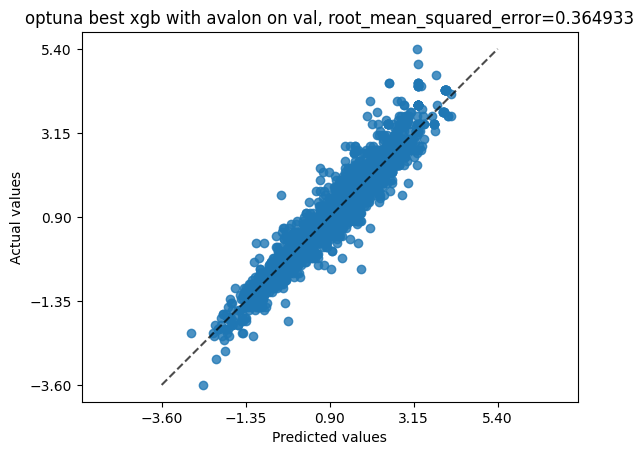

In [56]:
parity_plot(
    estimator=pipe,
    x=val_ids,
    y_true=y_val,
    title="optuna best xgb with avalon on val",
)

# GridSearchCV all fingerprints with MLP

## (128, ), (128, 128) with early stopping

In [25]:
for s in glob.glob("./data/*X_data.npy"):
    n_features = Path(s).stem.split('_')[1]
    n_features = int(n_features)


2048
2048
2048
2048
2048
167
1024


In [28]:
pipe_mlp = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    '/content/data/MorganFingerprint_2048_X_data.npy',
     regressor__model=MLPRegressor(
         random_state=42,
         early_stopping=True,
         validation_fraction=0.2,
    )
)

param_grid_mlp = {
    'regressor__fp_transform__path': glob.glob("./data/*X_data.npy"),
    'regressor__model__hidden_layer_sizes': [(128,), (128, 128)],
}

gscv_mlp = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid_mlp,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    verbose=3,
)

In [29]:
# 16 min
gscv_mlp.fit(X=train_ids, y=y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.516 total time=  24.3s
[CV 2/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.501 total time=  12.7s
[CV 3/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.518 total time=  10.6s
[CV 4/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.524 total time=  11.9s
[CV 5/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.501 total time=   9.6s
[CV 1/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(1

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                FpFromFileTransform(path='/content/data/MorganFingerprint_2048_X_data.npy')),
                                                                                               ('model',
                                                                                                MLPRegressor(early_stopping=True,
                                                                                                             random_state=42,
                                                                                                             validation_fraction=0.2))]),
                                                                     transformer=StandardScaler...
                                                           './data/FeaturesMorganFingerprint_2048_X_data.npy',
                                                           './data/TopologicalTorsionFingerprint_2048_X_data.npy',
                                                           './data/RDKitFingerprint_2048_X_data.npy',
                                                           './data/AtomPairFingerprint_2048_X_data.npy',
                                                           './data/MACCSKeysFingerprint_167_X_data.npy',
                                                           './data/AvalonFingerprint_1024_X_data.npy'],
                         'regressor__model__hidden_layer_sizes': [(128,),
                                                                  (128, 128)]},
             verbose=3)

In [31]:
gscv_mlp.best_params_

{'regressor__fp_transform__path': './data/AvalonFingerprint_1024_X_data.npy',
 'regressor__model__hidden_layer_sizes': (128, 128)}

In [33]:
gscv_mlp.best_score_

np.float64(-0.3058485807322032)

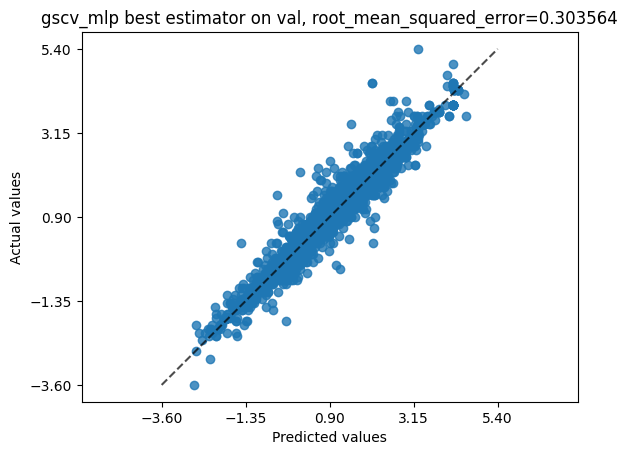

In [35]:
parity_plot(
    estimator=gscv_mlp.best_estimator_,
    x=val_ids,
    y_true=y_val,
    title="gscv_mlp best estimator on val",
)

## (128,) (128, 128) no early stopping

In [37]:
pipe_mlp_no_early = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    '/content/data/MorganFingerprint_2048_X_data.npy',
     regressor__model=MLPRegressor(
         random_state=42,
         early_stopping=False,
         #validation_fraction=0.2,
    )
)

param_grid_mlp_no_early = {
    'regressor__fp_transform__path': glob.glob("./data/*X_data.npy"),
    'regressor__model__hidden_layer_sizes': [(128,), (128, 128)],
}

gscv_mlp_no_early = GridSearchCV(
    estimator=pipe_mlp_no_early,
    param_grid=param_grid_mlp_no_early,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    verbose=3,
)

In [38]:
# 38 min
gscv_mlp_no_early.fit(X=train_ids, y=y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.493 total time=  23.0s
[CV 2/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.497 total time=  25.4s
[CV 3/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.499 total time=  19.8s
[CV 4/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.501 total time=  23.7s
[CV 5/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(128,);, score=-0.489 total time=  18.5s
[CV 1/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(1

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                FpFromFileTransform(path='/content/data/MorganFingerprint_2048_X_data.npy')),
                                                                                               ('model',
                                                                                                MLPRegressor(random_state=42))]),
                                                                     transformer=StandardScaler()),
             param_grid={'regressor__fp_transform__pa...
                                                           './data/FeaturesMorganFingerprint_2048_X_data.npy',
                                                           './data/TopologicalTorsionFingerprint_2048_X_data.npy',
                                                           './data/RDKitFingerprint_2048_X_data.npy',
                                                           './data/AtomPairFingerprint_2048_X_data.npy',
                                                           './data/MACCSKeysFingerprint_167_X_data.npy',
                                                           './data/AvalonFingerprint_1024_X_data.npy'],
                         'regressor__model__hidden_layer_sizes': [(128,),
                                                                  (128, 128)]},
             verbose=3)

In [39]:
gscv_mlp_no_early.best_params_

{'regressor__fp_transform__path': './data/AvalonFingerprint_1024_X_data.npy',
 'regressor__model__hidden_layer_sizes': (128, 128)}

In [40]:
gscv_mlp_no_early.best_score_

np.float64(-0.29003701342641797)

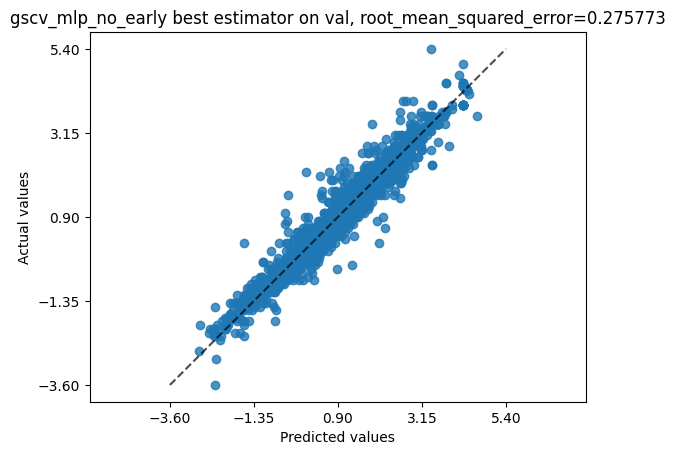

In [41]:
parity_plot(
    estimator=gscv_mlp_no_early.best_estimator_,
    x=val_ids,
    y_true=y_val,
    title="gscv_mlp_no_early best estimator on val",
)

## (512,), (512, 128) with early stopping

In [42]:
pipe_mlp_512 = construct_pipeline_with_specified_model_and_fp_from_pregenerated_file(
    '/content/data/MorganFingerprint_2048_X_data.npy',
     regressor__model=MLPRegressor(
         random_state=42,
         early_stopping=True,
         validation_fraction=0.2,
    )
)

param_grid_mlp_512 = {
    'regressor__fp_transform__path': glob.glob("./data/*X_data.npy"),
    'regressor__model__hidden_layer_sizes': [(512,), (512, 128)],
}

gscv_mlp_512 = GridSearchCV(
    estimator=pipe_mlp_512,
    param_grid=param_grid_mlp_512,
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    verbose=3,
)

In [43]:
gscv_mlp_512.fit(X=train_ids, y=y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(512,);, score=-0.503 total time=  34.4s
[CV 2/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(512,);, score=-0.481 total time= 1.0min
[CV 3/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(512,);, score=-0.488 total time=  28.9s
[CV 4/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(512,);, score=-0.503 total time= 1.2min
[CV 5/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(512,);, score=-0.496 total time=  33.9s
[CV 1/5] END regressor__fp_transform__path=./data/MorganFingerprint_2048_X_data.npy, regressor__model__hidden_layer_sizes=(5

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor_with_custom_metric(regressor=Pipeline(steps=[('fp_transform',
                                                                                                FpFromFileTransform(path='/content/data/MorganFingerprint_2048_X_data.npy')),
                                                                                               ('model',
                                                                                                MLPRegressor(early_stopping=True,
                                                                                                             random_state=42,
                                                                                                             validation_fraction=0.2))]),
                                                                     transformer=StandardScaler...
                                                           './data/FeaturesMorganFingerprint_2048_X_data.npy',
                                                           './data/TopologicalTorsionFingerprint_2048_X_data.npy',
                                                           './data/RDKitFingerprint_2048_X_data.npy',
                                                           './data/AtomPairFingerprint_2048_X_data.npy',
                                                           './data/MACCSKeysFingerprint_167_X_data.npy',
                                                           './data/AvalonFingerprint_1024_X_data.npy'],
                         'regressor__model__hidden_layer_sizes': [(512,),
                                                                  (512, 128)]},
             verbose=3)

In [44]:
gscv_mlp_512.best_params_

{'regressor__fp_transform__path': './data/AvalonFingerprint_1024_X_data.npy',
 'regressor__model__hidden_layer_sizes': (512, 128)}

In [45]:
gscv_mlp_512.best_score_

np.float64(-0.2912556436186361)

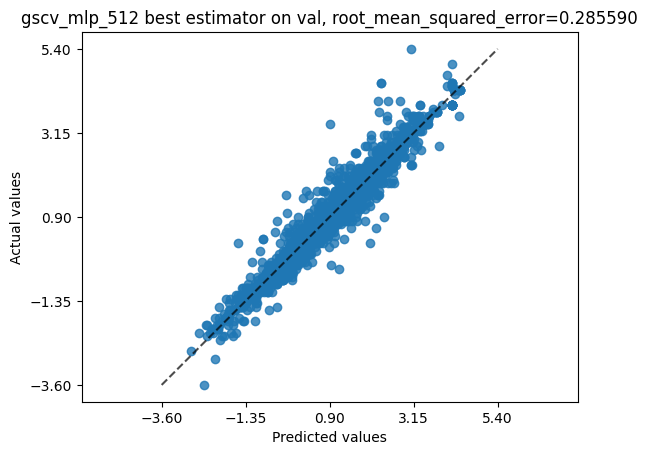

In [46]:
parity_plot(
    estimator=gscv_mlp_512.best_estimator_,
    x=val_ids,
    y_true=y_val,
    title="gscv_mlp_512 best estimator on val",
)